<a href="https://colab.research.google.com/github/zaibshahzadi/ML-Internship/blob/main/Titanic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [8]:
df=pd.read_csv("Titanic-Dataset.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [9]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

data = df[features + [target]].dropna()

X = data[features]   # inputs
y = data[target]     # output (survived or not)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ])

In [11]:
dt_pipeline = Pipeline([("preprocess", preprocessor),
                        ("model", DecisionTreeClassifier(random_state=42))])

knn_pipeline = Pipeline([("preprocess", preprocessor),
                         ("model", KNeighborsClassifier(n_neighbors=5))])

nb_pipeline = Pipeline([("preprocess", preprocessor),
                        ("model", GaussianNB())])

In [12]:
pipelines = {"Decision Tree": dt_pipeline,
             "kNN": knn_pipeline,
             "Naive Bayes": nb_pipeline}

results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Decision Tree Results:
Accuracy: 0.6853146853146853
              precision    recall  f1-score   support

           0       0.70      0.78      0.73        80
           1       0.67      0.57      0.62        63

    accuracy                           0.69       143
   macro avg       0.68      0.67      0.67       143
weighted avg       0.68      0.69      0.68       143

Confusion Matrix:
 [[62 18]
 [27 36]]

kNN Results:
Accuracy: 0.7552447552447552
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        80
           1       0.76      0.65      0.70        63

    accuracy                           0.76       143
   macro avg       0.76      0.74      0.75       143
weighted avg       0.76      0.76      0.75       143

Confusion Matrix:
 [[67 13]
 [22 41]]

Naive Bayes Results:
Accuracy: 0.7622377622377622
              precision    recall  f1-score   support

           0       0.78      0.80      0.79        80
           1  

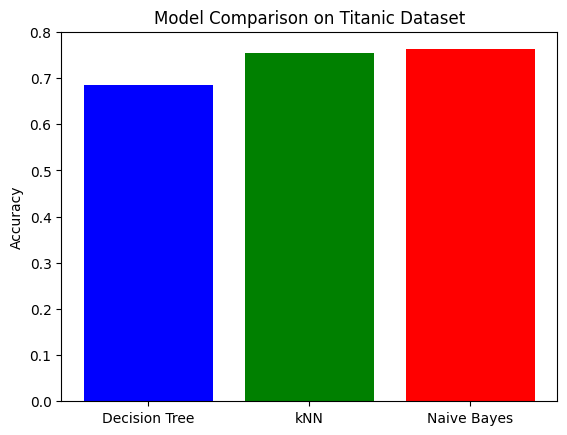

In [13]:
plt.bar(results.keys(), results.values(), color=["blue","green","red"])
plt.ylabel("Accuracy")
plt.title("Model Comparison on Titanic Dataset")
plt.show()

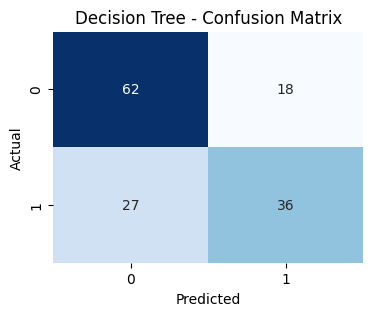

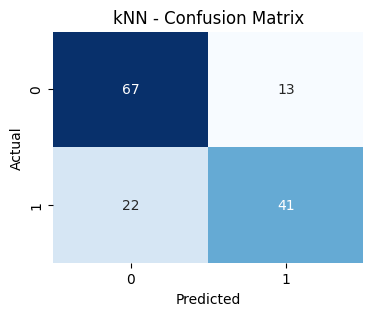

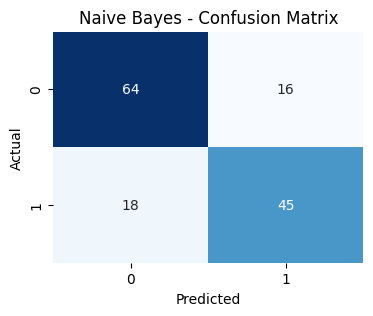

In [14]:
import seaborn as sns

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()